<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/LangStudio/RSI_Max_Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

##RSI Max

This notebook performs a comprehensive parameter sweep to optimize a Relative Strength Index (RSI) trading strategy. It backtests various combinations of RSI lengths and entry thresholds across a defined set of symbols to identify tickers with strong RSI readings that tend to perform well over the short term. For each parameter set, it calculates and analyzes 3-day, 5-day, and 10-day future returns and win rates. The results are summarized and visualized using heatmaps to identify the most effective RSI configurations for potential bearish signals.

In [9]:
# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

In [10]:
warnings.filterwarnings("ignore")

# --- 1. Configuration & Symbol Loading ---
# Bearish thresholds (Overbought levels)
RSI_LEVELS = [60, 65, 70, 75, 80]
RSI_LENGTHS = [3, 5, 7, 10, 12, 14, 16, 18, 22, 24, 26]

try:
    # Using your specific filename mentioned in previous turns
    df_csv = pd.read_csv(OptionVolume)
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower() or 'ticker' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from OptionVolume")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT"]

# --- 2. Enhanced RSI Function ---
def calculate_rsi_yahoo(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# --- 3. Data Fetching ---
print("Fetching data and calculating vectorized returns...")
data_cache = {}
for s in SYMBOLS:
    try:
        # auto_adjust=True handles splits/dividends; multi_level=False prevents MultiIndex
        df = yf.download(s, period="5y", interval="1d", progress=False, auto_adjust=True)
        if df.empty: continue

        # Ensure column names are clean
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Vectorized Future Returns (The "Trade" result)
        df['Ret_3D'] = df['Close'].pct_change(3).shift(-3)
        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)
        df['Ret_10D'] = df['Close'].pct_change(10).shift(-10)

        data_cache[s] = df
    except:
        continue

# --- 4. Parameter Sweep ---
all_results = []
all_individual_trades_list = [] # New list to store all individual trade DataFrames

for rsi_len in RSI_LENGTHS:
    for rsi_thresh in RSI_LEVELS:
        param_trades = []

        for symbol, df_orig in data_cache.items():
            df = df_orig.copy()
            df['RSI'] = calculate_rsi_yahoo(df['Close'], period=rsi_len)

            # --- UPDATED TRIGGER LOGIC: THE CROSSOVER ---
            # 1. Current RSI is above threshold
            # 2. Previous RSI was below or equal to threshold
            condition = (df['RSI'] > rsi_thresh) & (df['RSI'].shift(1) <= rsi_thresh)

            trades = df[condition].dropna(subset=['Ret_10D']).copy()

            if not trades.empty:
                trades['RSI_Len'] = rsi_len
                trades['RSI_Thresh'] = rsi_thresh
                param_trades.append(trades)

        if param_trades:
            combined = pd.concat(param_trades)
            all_individual_trades_list.append(combined) # Store this combined DataFrame
            # BEARISH WIN RATE: A win is when future return is NEGATIVE (< 0)
            all_results.append({
                "RSI_Len": rsi_len,
                "RSI_Thresh": rsi_thresh,
                "Avg_3D_Ret": combined['Ret_3D'].mean(),
                "Avg_5D_Ret": combined['Ret_5D'].mean(),
                "Avg_10D_Ret": combined['Ret_10D'].mean(),
                "Win_Rate_3D": (combined['Ret_3D'] > 0).mean(),
                "Win_Rate_5D": (combined['Ret_5D'] > 0).mean(),
                "Win_Rate_10D": (combined['Ret_10D'] > 0).mean(),
                "Trade_Count": len(combined)
            })

# Create a single DataFrame containing all individual trades from all parameter combinations
if all_individual_trades_list:
    all_combined_trades_df = pd.concat(all_individual_trades_list)
else:
    all_combined_trades_df = pd.DataFrame() # Create an empty DataFrame if no trades found

# --- 5. Summary Display ---
if all_results:
    summary_df = pd.DataFrame(all_results)
    # Sorting by Win_Rate_5D to find the best bearish signals
    summary_df = summary_df.sort_values(by="Win_Rate_5D", ascending=False)
    #summary_df = summary_df.sort_values(by="Avg_5D_Ret", ascending=False)

    print("\n--- BEARISH RSI OPTIMIZATION SUMMARY ---")
    display(summary_df)
    summary_df.to_csv("bearish_rsi_results.csv", index=False)
else:
    print("No bearish signals found.")


Loaded 100 symbols from OptionVolume
Fetching data and calculating vectorized returns...

--- BEARISH RSI OPTIMIZATION SUMMARY ---


,RSI_Len,RSI_Thresh,Avg_3D_Ret,Avg_5D_Ret,Avg_10D_Ret,Win_Rate_3D,Win_Rate_5D,Win_Rate_10D,Trade_Count
28,14,75,0.011560,0.015587,0.032900,0.575988,0.598784,0.624620,1316
33,16,75,0.011742,0.017609,0.033859,0.564202,0.595331,0.612840,1028
19,10,80,0.011740,0.016569,0.036551,0.569065,0.591398,0.642680,1209
38,18,75,0.015049,0.019447,0.037019,0.554863,0.587282,0.618454,802
43,22,75,0.013665,0.016189,0.035816,0.565815,0.579568,0.589391,509
23,12,75,0.009529,0.013370,0.030928,0.559158,0.578498,0.613197,1758
42,22,70,0.009620,0.014067,0.031389,0.543807,0.577039,0.601208,1324
37,18,70,0.008955,0.014334,0.030023,0.548847,0.575192,0.589462,1822
24,12,80,0.012392,0.015230,0.035714,0.555970,0.573383,0.624378,804
48,24,75,0.013381,0.015637,0.043204,0.562500,0.571759,0.601852,432


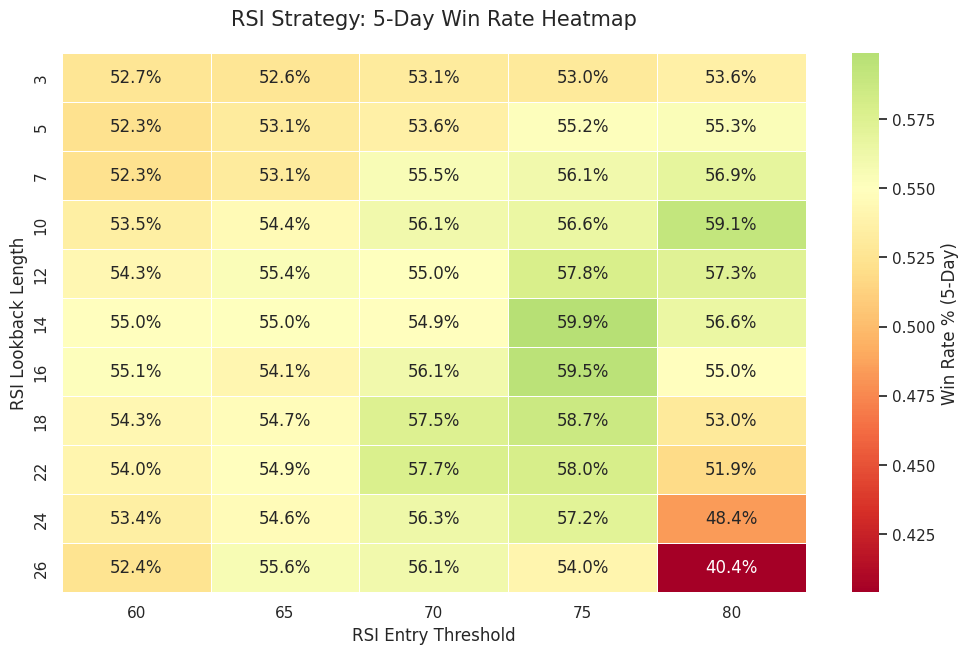

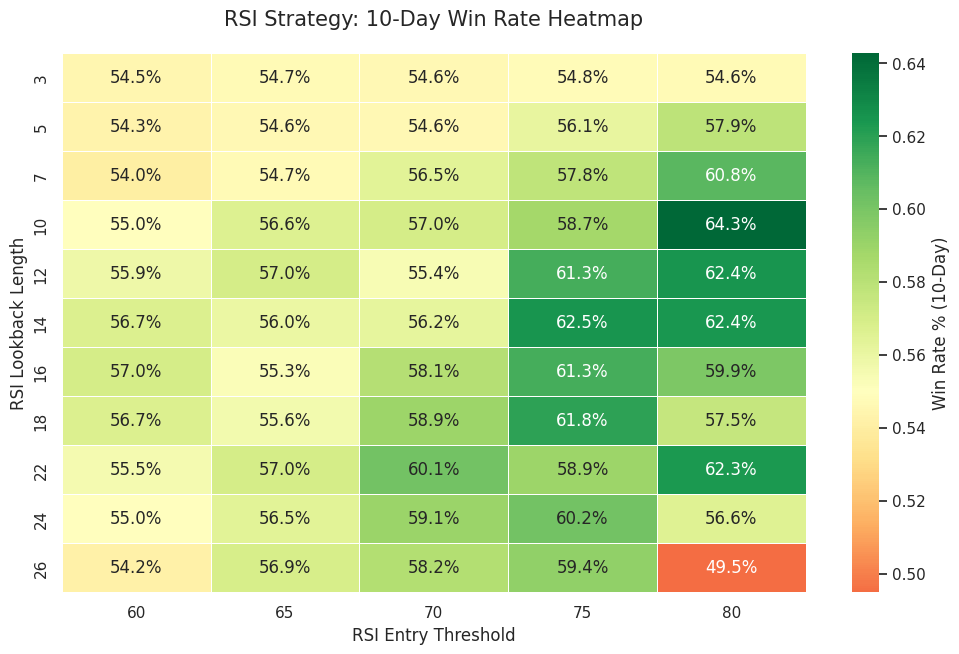

In [11]:
# 1. Pivot the data for 5-Day Win Rate
heatmap_data_5d = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Win_Rate_5D")

# 2. Set up the figure for 5-Day Win Rate Heatmap
plt.figure(figsize=(12, 7))

# 3. Create the heatmap for 5-Day Win Rate
sns.heatmap(
    heatmap_data_5d,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    vmin=summary_df["Win_Rate_5D"].min(),
    vmax=summary_df["Win_Rate_5D"].max(),
    center=0.55,
    linewidths=.5,
    cbar_kws={'label': 'Win Rate % (5-Day)'}
)

# 4. Labels for 5-Day Win Rate Heatmap
plt.title("RSI Strategy: 5-Day Win Rate Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

# --- Separator for 10-Day Win Rate Heatmap ---

# 1. Pivot the data for 10-Day Win Rate
heatmap_data_10d = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Win_Rate_10D")

# 2. Set up the figure for 10-Day Win Rate Heatmap
plt.figure(figsize=(12, 7))

# 3. Create the heatmap for 10-Day Win Rate
sns.heatmap(
    heatmap_data_10d,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    vmin=summary_df["Win_Rate_10D"].min(),
    vmax=summary_df["Win_Rate_10D"].max(),
    center=0.55,
    linewidths=.5,
    cbar_kws={'label': 'Win Rate % (10-Day)'}
)

# 4. Labels for 10-Day Win Rate Heatmap
plt.title("RSI Strategy: 10-Day Win Rate Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

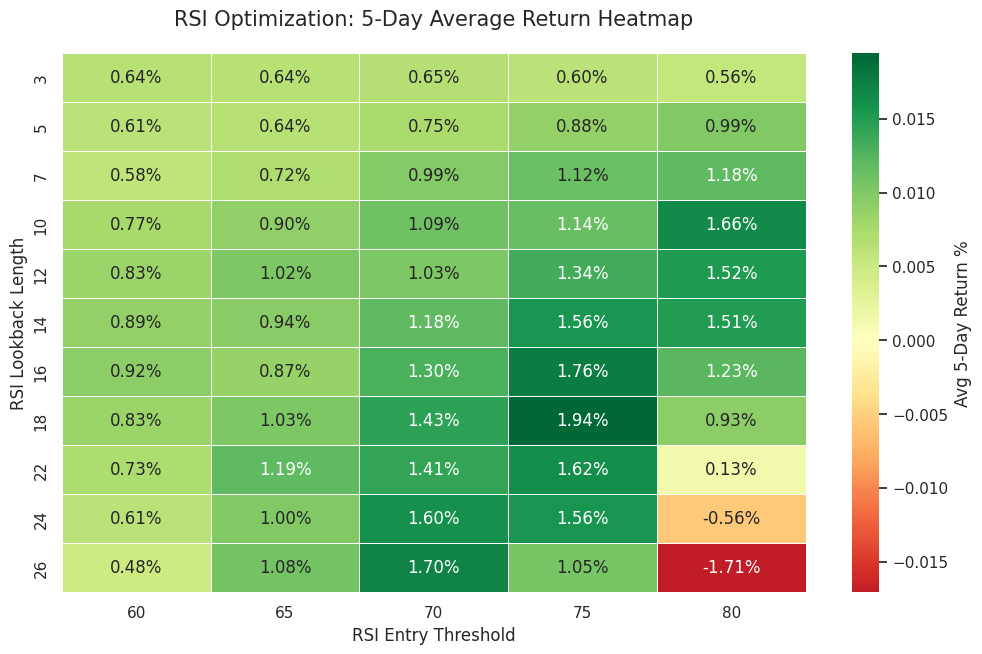

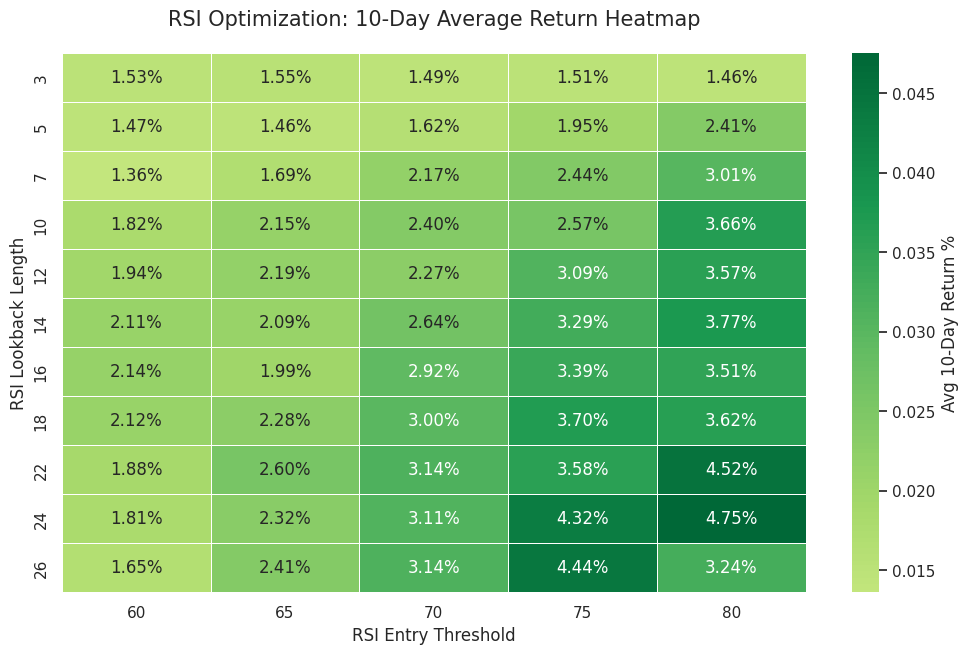

In [12]:
# Average Return Heatmaps
# 1. Pivot the data for Average 5-Day Return
heatmap_data_5d_avg = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Avg_5D_Ret")

# 2. Set up the figure for Average 5-Day Return Heatmap
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

# 3. Create the heatmap with optimized gradient parameters
# vmin/vmax: Stretches the color range to your specific best and worst performers
# center=0: Ensures the color transition happens exactly at the break-even point
sns.heatmap(
    heatmap_data_5d_avg,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    vmin=summary_df["Avg_5D_Ret"].min(),
    vmax=summary_df["Avg_5D_Ret"].max(),
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Avg 5-Day Return %'}
)

# 4. Labels and Title
plt.title("RSI Optimization: 5-Day Average Return Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

# --- Separator for Average 10-Day Return Heatmap ---

# 1. Pivot the data for Average 10-Day Return
heatmap_data_10d_avg = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Avg_10D_Ret")

# 2. Set up the figure for Average 10-Day Return Heatmap
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

# 3. Create the heatmap with optimized gradient parameters
sns.heatmap(
    heatmap_data_10d_avg,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    vmin=summary_df["Avg_10D_Ret"].min(),
    vmax=summary_df["Avg_10D_Ret"].max(),
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Avg 10-Day Return %'}
)

# 4. Labels and Title
plt.title("RSI Optimization: 10-Day Average Return Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

### Monthly Performance Analysis for Specific RSI Parameters

Analyze the monthly performance (win rate and average return) for a chosen RSI Length and Threshold. This helps to see the consistency of the strategy over time.

In [18]:
target_rsi_len = 14  # @param {type: "raw"}
target_rsi_thresh = 75 # @param {type: "raw"}
trade_size_dollars = 1000 # @param {type: "raw"} Default trade size in dollars

# Filter the all_combined_trades_df for the selected RSI_Len and RSI_Thresh
monthly_trades = all_combined_trades_df[
    (all_combined_trades_df['RSI_Len'] == target_rsi_len) &
    (all_combined_trades_df['RSI_Thresh'] == target_rsi_thresh)
].copy()

if not monthly_trades.empty:
    # Ensure 'Date' is datetime and set as index if not already
    monthly_trades.index = pd.to_datetime(monthly_trades.index)

    # Extract Year and Month
    monthly_trades['Year'] = monthly_trades.index.year
    monthly_trades['Month'] = monthly_trades.index.month

    # Group by Year and Month and calculate performance metrics for 3D, 5D, and 10D
    monthly_performance = monthly_trades.groupby(['Year', 'Month']).agg(
        Trade_Count=('Ret_5D', 'count'), # Assuming trade count is consistent across Ret_nD
        Avg_3D_Ret=('Ret_3D', 'mean'),
        Win_Rate_3D=('Ret_3D', lambda x: (x > 0).mean()),
        Avg_5D_Ret=('Ret_5D', 'mean'),
        Win_Rate_5D=('Ret_5D', lambda x: (x > 0).mean()),
        Avg_10D_Ret=('Ret_10D', 'mean'),
        Win_Rate_10D=('Ret_10D', lambda x: (x > 0).mean())
    ).reset_index()

    # Calculate Monthly Dollar Return for 3D, 5D, and 10D, and Cumulative Monthly Dollar Value (based on 5D)
    monthly_performance['Monthly_Return_3D'] = monthly_performance['Trade_Count'] * monthly_performance['Avg_3D_Ret'] * trade_size_dollars
    monthly_performance['Monthly_Return_5D'] = monthly_performance['Trade_Count'] * monthly_performance['Avg_5D_Ret'] * trade_size_dollars
    monthly_performance['Monthly_Return_10D'] = monthly_performance['Trade_Count'] * monthly_performance['Avg_10D_Ret'] * trade_size_dollars
    monthly_performance['Cumulative_Monthly_Dollar_Value'] = monthly_performance['Monthly_Return_5D'].cumsum()

    print(f"\n--- Monthly Performance for RSI_Len={target_rsi_len}, RSI_Thresh={target_rsi_thresh} (Trade Size: ${trade_size_dollars}) ---")
    # Display the monthly performance, focusing on all relevant monthly metrics
    display(monthly_performance[[
        'Year', 'Month', 'Trade_Count',
        'Avg_3D_Ret', 'Win_Rate_3D', 'Monthly_Return_3D',
        'Avg_5D_Ret', 'Win_Rate_5D', 'Monthly_Return_5D',
        'Avg_10D_Ret', 'Win_Rate_10D', 'Monthly_Return_10D'
    ]])
else:
    print(f"No trades found for RSI_Len={target_rsi_len}, RSI_Thresh={target_rsi_thresh} in the collected trades.")


--- Monthly Performance for RSI_Len=14, RSI_Thresh=75 (Trade Size: $1000) ---


,Year,Month,Trade_Count,Avg_3D_Ret,Win_Rate_3D,Monthly_Return_3D,Avg_5D_Ret,Win_Rate_5D,Monthly_Return_5D,Avg_10D_Ret,Win_Rate_10D,Monthly_Return_10D
0,2021,6,18,0.007409,0.722222,133.367580,0.016585,0.833333,298.525758,0.027513,0.888889,495.237197
1,2021,7,37,-0.001875,0.486486,-69.389107,0.003291,0.675676,121.758921,0.003470,0.648649,128.378123
2,2021,8,25,0.009649,0.480000,241.230410,0.010371,0.480000,259.266928,0.007555,0.440000,188.886191
3,2021,9,11,0.008905,0.363636,97.954752,-0.026619,0.363636,-292.805058,-0.038061,0.181818,-418.673754
4,2021,10,26,0.015032,0.615385,390.838239,0.042125,0.769231,1095.238829,0.081617,0.692308,2122.045064
5,2021,11,41,0.010610,0.536585,435.014484,-0.001470,0.560976,-60.257660,-0.005558,0.463415,-227.870192
6,2021,12,12,-0.003197,0.416667,-38.365990,-0.002243,0.583333,-26.917108,0.000550,0.583333,6.605007
7,2022,1,10,0.012007,0.700000,120.071444,0.022494,0.800000,224.942016,0.035664,0.900000,356.636243
8,2022,2,5,-0.007080,0.400000,-35.401803,0.004341,0.800000,21.704698,0.013726,0.400000,68.629783
9,2022,3,15,-0.005165,0.400000,-77.482221,-0.001141,0.400000,-17.110355,-0.024716,0.266667,-370.746910


### Yearly Performance Analysis

In [19]:
if not monthly_performance.empty:
    yearly_performance = monthly_performance.groupby('Year').agg(
        Yearly_Return_3D=('Monthly_Return_3D', 'sum'),
        Yearly_Return_5D=('Monthly_Return_5D', 'sum'),
        Yearly_Return_10D=('Monthly_Return_10D', 'sum')
    ).reset_index()

    print(f"\n--- Yearly Performance for RSI_Len={target_rsi_len}, RSI_Thresh={target_rsi_thresh} (Trade Size: ${trade_size_dollars}) ---")
    display(yearly_performance)
else:
    print("No monthly performance data to aggregate for yearly analysis.")


--- Yearly Performance for RSI_Len=14, RSI_Thresh=75 (Trade Size: $1000) ---


,Year,Yearly_Return_3D,Yearly_Return_5D,Yearly_Return_10D
0,2021,1190.650369,1394.810609,2294.607638
1,2022,-62.765079,-402.514874,-477.234591
2,2023,1891.262806,2551.671557,5081.444271
3,2024,4569.055364,4584.808973,12033.735687
4,2025,4551.802756,7006.417195,13478.604133
5,2026,3073.035099,5376.896291,10884.604510
